# 08: Interpretability, SHAP, and Segments

We focus on explaining heterogeneous treatment-effect models after they have been fit.

CATE models can estimate a different treatment effect for every unit. That is powerful, but it creates a communication problem:

> Why does the model believe some units benefit more than others, and where should we trust that story?

This lesson uses three complementary explanation layers:

- global feature importance from the EconML CATE model;
- SHAP-style explanations of a surrogate model trained to mimic CATE predictions;
- segment-level summaries that turn unit-level estimates into auditable groups.

The most important habit in this lesson is restraint. Explanation tools describe the fitted model. They do not prove that a feature is causally valid, that confounding is solved, or that a targeting rule is ready to deploy.

## Learning Goals

By the end, you should be able to:

- explain why CATE model explanations require extra care;
- fit a flexible EconML CATE model and inspect feature importance;
- train a high-fidelity surrogate model on CATE estimates;
- use SHAP values to summarize how features move estimated CATE up or down;
- build local CATE explanation tables for individual units;
- compare model-level explanations with truth-known simulation drivers;
- create segment summaries, heatmaps, and effect slices;
- identify support and uncertainty risks in high-benefit groups;
- write responsible caveats for CATE explanation outputs.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use synthetic or semi-synthetic treatment-effect datasets with observable oracle effects to study **Interpretability, SHAP, And Segments**. Known treatment-effect surfaces let us check whether CATE, policy, interval, and interpretability tools recover the right heterogeneity pattern.

Read each row as a customer, user, patient, seller, or operational unit with covariates measured before treatment. Effect modifiers drive heterogeneity, while controls and propensities create the observational difficulty. The experiment uses explanation tools for estimated treatment effects. The explanations describe model behavior and should not be confused with new causal identification evidence.

The oracle columns are teaching instruments. In a real deployment, those columns would not exist, so diagnostics, overlap checks, uncertainty, and sensitivity analysis become essential.


## Mathematical Foundation

<!-- math-foundation-note -->

Interpreting a treatment-effect model means explaining variation in $\widehat\tau(X)$, not explaining the observed outcome directly. A feature attribution method decomposes a prediction around a baseline,

$$
\widehat\tau(x) \approx \phi_0+\sum_{j=1}^{p}\phi_j(x).
$$

The attribution values explain the fitted CATE model. They are not proof that the features cause the treatment effect to differ.





## Tutorial Workflow

### What Explanation Tools Can and Cannot Say

Feature importance, SHAP values, and segment summaries answer questions about the fitted model:

- Which features does the model use most?
- Which features push an estimated CATE higher or lower for a row?
- Which segments have higher or lower estimated effects?
- Which segments have wider uncertainty or weaker support?

They do not answer causal-design questions by themselves:

- They do not prove a feature should be adjusted for.
- They do not prove unconfoundedness.
- They do not fix post-treatment leakage.
- They do not replace overlap checks.
- They do not make noisy individual treatment effects reliable.

The right mental model is: explanation tools help audit and communicate a fitted CATE model after the causal design has already been specified.


We follow this path:

1. Create a truth-known heterogeneous treatment-effect dataset.
2. Fit `CausalForestDML` with intervals.
3. Check CATE recovery and feature importance.
4. Train a surrogate model to mimic forest CATE predictions.
5. Use SHAP values on the surrogate CATE model.
6. Build local explanation tables for selected units.
7. Summarize CATE by segments and feature slices.
8. Compare feature importance, SHAP, and permutation sensitivity.
9. Close with a reporting checklist for CATE explanations.



#### Setup

The code below imports the packages used in the lesson, creates output folders, fixes a random seed, and checks whether EconML and SHAP are available.

In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import warnings
import importlib.metadata as importlib_metadata

# Keep Matplotlib cache files in a writable location during notebook execution.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ranking-sys")

warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")
warnings.filterwarnings("ignore", message=".*The final model has a nonzero intercept.*")
warnings.filterwarnings("ignore", message=".*Co-variance matrix is underdetermined.*")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")

import numpy as np

# Compatibility shim for older SHAP/EconML imports under NumPy 2.x.
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_
if not hasattr(np, "obj2sctype"):
    def _numpy_obj2sctype_compat(rep, default=None):
        try:
            return np.dtype(rep).type
        except TypeError:
            return default

    np.obj2sctype = _numpy_obj2sctype_compat
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from IPython.display import display
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import brier_score_loss, log_loss, mean_squared_error, roc_auc_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict, train_test_split

try:
    import econml
    from econml.dml import CausalForestDML, LinearDML
    ECONML_AVAILABLE = True
    ECONML_VERSION = getattr(econml, "__version__", "unknown")
except Exception as exc:
    ECONML_AVAILABLE = False
    ECONML_VERSION = f"import failed: {type(exc).__name__}: {exc}"

try:
    SHAP_VERSION = getattr(shap, "__version__", importlib_metadata.version("shap"))
    SHAP_AVAILABLE = True
except Exception as exc:
    SHAP_VERSION = f"import failed: {type(exc).__name__}: {exc}"
    SHAP_AVAILABLE = False

RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"EconML available: {ECONML_AVAILABLE}")
print(f"EconML version: {ECONML_VERSION}")
print(f"SHAP available: {SHAP_AVAILABLE}")
print(f"SHAP version: {SHAP_VERSION}")
print(f"Figures will be saved to: {FIGURE_DIR.resolve()}")
print(f"Tables will be saved to: {TABLE_DIR.resolve()}")


IPython could not be loaded!


EconML available: True
EconML version: 0.16.0
SHAP available: True
SHAP version: 0.39.0
Figures will be saved to: /home/apex/Documents/portfolio/notebooks/tutorials/econml/outputs/figures
Tables will be saved to: /home/apex/Documents/portfolio/notebooks/tutorials/econml/outputs/tables


The notebook can use EconML for CATE estimation and SHAP for explanation. The outputs are saved with the `08_` prefix.

This is a reproducibility check rather than causal evidence. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


### Explanation Map

The next table separates the explanation tools used in this lesson. Each tool has a different job.

| tool | what it explains | best use | main caveat |
| --- | --- | --- | --- |
| Causal forest feature importance | Which X features the fitted forest uses most for treatment-effect heterogeneity | Quick global model audit | Importance is about the fitted model, not proof of causal validity |
| Permutation CATE sensitivity | How much CATE predictions change when one feature is shuffled | Model-agnostic global sensitivity check | Correlated features can share or hide importance |
| SHAP on CATE surrogate | How features push a surrogate CATE prediction up or down | Global and local decomposition of estimated CATE | Explains the surrogate of the CATE model, so surrogate fidelity must be checked |
| Segment summaries | Average estimated effect, true effect, support, and uncertainty by group | Readable reporting and audit tables | Segments can hide within-segment variation |


No single explanation table is enough. We will triangulate across several views so the final story is less brittle.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


#### Synthetic Example Data

The dataset below has observed confounding and nonlinear treatment-effect heterogeneity. We keep the true CATE because this is a teaching notebook. In real analyses, we would not know it.

The true CATE depends on several features through thresholds, nonlinear terms, and interactions. That makes it a good fit for a flexible CATE model and a good test case for explanation tools.

In [2]:
# Define reusable helpers for the Synthetic Example Data section.
n = 3_200

baseline_need = rng.normal(0, 1, size=n)
prior_engagement = rng.normal(0, 1, size=n)
friction_score = 0.52 * baseline_need - 0.25 * prior_engagement + rng.normal(0, 0.85, size=n)
content_affinity = 0.40 * prior_engagement + rng.normal(0, 0.95, size=n)
price_sensitivity = rng.normal(0, 1, size=n)
trust_score = rng.normal(0, 1, size=n)
recency_gap = rng.normal(0, 1, size=n)
region_risk = rng.binomial(1, 0.35, size=n)
high_need_segment = (baseline_need > 0.55).astype(int)

account_tenure = rng.normal(0, 1, size=n)
seasonality_index = rng.normal(0, 1, size=n)
device_stability = rng.normal(0, 1, size=n)
traffic_intensity = rng.normal(0, 1, size=n)

propensity_logit = (
    -0.28
    + 0.78 * baseline_need
    + 0.44 * prior_engagement
    + 0.40 * friction_score
    + 0.32 * content_affinity
    - 0.18 * trust_score
    + 0.26 * region_risk
    + 0.24 * high_need_segment
    - 0.28 * account_tenure
    + 0.22 * seasonality_index
    + 0.16 * traffic_intensity
)
propensity = 1 / (1 + np.exp(-propensity_logit))
propensity = np.clip(propensity, 0.035, 0.965)
treatment = rng.binomial(1, propensity, size=n)

def true_cate_function(frame):
    """
    Idea: Evaluate the true CATE function used by the simulator or nuisance-model diagnostic.
    
    Parameters
    ----------
    frame : pd.DataFrame
        Table-like object being transformed.
    
    Returns
    -------
    pd.Series or np.ndarray
        Oracle row-level CATE values generated from the synthetic treatment-effect function.
    """
    return (
        0.40
        + 0.36 * frame["high_need_segment"].to_numpy()
        + 0.24 * np.tanh(frame["prior_engagement"].to_numpy())
        - 0.26 * np.maximum(frame["friction_score"].to_numpy(), 0)
        + 0.18 * frame["content_affinity"].to_numpy()
        - 0.16 * frame["region_risk"].to_numpy()
        - 0.12 * (frame["price_sensitivity"].to_numpy() > 0.75).astype(float)
        + 0.12 * np.sin(frame["content_affinity"].to_numpy() + frame["baseline_need"].to_numpy())
        + 0.10 * frame["high_need_segment"].to_numpy() * (frame["content_affinity"].to_numpy() > 0).astype(float)
    )

base_frame = pd.DataFrame(
    {
        "baseline_need": baseline_need,
        "prior_engagement": prior_engagement,
        "friction_score": friction_score,
        "content_affinity": content_affinity,
        "price_sensitivity": price_sensitivity,
        "region_risk": region_risk,
        "high_need_segment": high_need_segment,
    }
)
true_cate = true_cate_function(base_frame)

baseline_outcome = (
    2.10
    + 0.80 * baseline_need
    + 0.58 * prior_engagement
    - 0.48 * friction_score
    + 0.30 * content_affinity
    + 0.22 * trust_score
    + 0.34 * account_tenure
    + 0.22 * seasonality_index
    + 0.18 * device_stability
    + 0.16 * traffic_intensity
    + 0.16 * region_risk
    + 0.12 * baseline_need * friction_score
)
noise = rng.normal(0, 0.90, size=n)
outcome = baseline_outcome + true_cate * treatment + noise

teaching_df = pd.DataFrame(
    {
        "user_id": np.arange(n),
        "baseline_need": baseline_need,
        "prior_engagement": prior_engagement,
        "friction_score": friction_score,
        "content_affinity": content_affinity,
        "price_sensitivity": price_sensitivity,
        "trust_score": trust_score,
        "recency_gap": recency_gap,
        "region_risk": region_risk,
        "high_need_segment": high_need_segment,
        "account_tenure": account_tenure,
        "seasonality_index": seasonality_index,
        "device_stability": device_stability,
        "traffic_intensity": traffic_intensity,
        "propensity": propensity,
        "treatment": treatment,
        "outcome": outcome,
        "baseline_outcome_mean": baseline_outcome,
        "true_cate": true_cate,
    }
)

teaching_df.head()


,user_id,baseline_need,prior_engagement,friction_score,content_affinity,price_sensitivity,trust_score,recency_gap,region_risk,high_need_segment,account_tenure,seasonality_index,device_stability,traffic_intensity,propensity,treatment,outcome,baseline_outcome_mean,true_cate
0,0,-0.7931,-1.2901,-0.3487,-0.1556,-1.1530,-1.3164,-0.7477,1,0,-3.0473,-0.3020,-0.9402,2.2139,0.4956,0,-0.9732,-0.1760,-0.0917
1,1,0.2406,0.2599,-0.4707,0.3219,-0.9692,1.3240,-0.4711,0,0,-0.5008,-0.4229,1.2210,0.6131,0.4610,1,4.1260,3.0979,0.5829
2,2,-1.8963,-0.3197,-0.9355,-0.2171,-1.2255,-0.4610,0.0474,0,0,-0.0048,-0.8700,-1.7494,-0.0209,0.0791,0,2.7037,0.3816,0.1839
3,3,1.3958,-0.2729,0.3331,0.4374,0.6809,-1.5277,1.4382,0,1,1.0852,-0.2230,-2.3089,0.9227,0.7810,1,4.7509,2.8013,0.9041
4,4,0.6383,-1.4263,0.6745,-2.0093,0.5773,1.1598,2.8067,0,1,-1.8344,-0.9164,-0.2073,-0.3209,0.3797,0,0.0497,0.2497,-0.1085


The dataset contains the observed columns we would use in a real analysis plus oracle columns for simulation checks. The CATE surface is deliberately nonlinear so explanation tools have something meaningful to summarize.

#### Field Dictionary

The field dictionary prevents leakage. Oracle fields are useful for learning, but they must not be model inputs.

In [3]:
# Save the artifacts produced by the Field Dictionary section.
effect_modifier_cols = [
    "baseline_need",
    "prior_engagement",
    "friction_score",
    "content_affinity",
    "price_sensitivity",
    "region_risk",
    "high_need_segment",
]
control_cols = ["trust_score", "recency_gap", "account_tenure", "seasonality_index", "device_stability", "traffic_intensity"]
all_observed_covariates = effect_modifier_cols + control_cols
true_driver_cols = effect_modifier_cols.copy()

field_rows = []
for col in effect_modifier_cols:
    field_rows.append(
        {
            "column": col,
            "role": "X effect modifier",
            "observed_in_real_analysis": "yes",
            "description": "Pre-treatment feature used to explain CATE variation.",
            "true_cate_driver": "yes" if col in true_driver_cols else "no",
        }
    )
for col in control_cols:
    field_rows.append(
        {
            "column": col,
            "role": "W control",
            "observed_in_real_analysis": "yes",
            "description": "Pre-treatment feature used for nuisance adjustment and support checks.",
            "true_cate_driver": "no",
        }
    )
for col, role, description in [
    ("treatment", "treatment", "Binary treatment indicator."),
    ("outcome", "outcome", "Observed post-treatment outcome."),
    ("propensity", "oracle", "True treatment probability from the simulated assignment process."),
    ("baseline_outcome_mean", "oracle", "Mean untreated outcome component before noise."),
    ("true_cate", "oracle", "Known individual treatment effect used only for evaluation."),
]:
    field_rows.append(
        {
            "column": col,
            "role": role,
            "observed_in_real_analysis": "yes" if role in ["treatment", "outcome"] else "no",
            "description": description,
            "true_cate_driver": "not applicable",
        }
    )

field_dictionary = pd.DataFrame(field_rows)
field_dictionary.to_csv(TABLE_DIR / "08_field_dictionary.csv", index=False)
display(field_dictionary)


,column,role,observed_in_real_analysis,description,true_cate_driver
0,baseline_need,X effect modifier,yes,Pre-treatment feature used to explain CATE variation.,yes
1,prior_engagement,X effect modifier,yes,Pre-treatment feature used to explain CATE variation.,yes
2,friction_score,X effect modifier,yes,Pre-treatment feature used to explain CATE variation.,yes
3,content_affinity,X effect modifier,yes,Pre-treatment feature used to explain CATE variation.,yes
4,price_sensitivity,X effect modifier,yes,Pre-treatment feature used to explain CATE variation.,yes
5,region_risk,X effect modifier,yes,Pre-treatment feature used to explain CATE variation.,yes
6,high_need_segment,X effect modifier,yes,Pre-treatment feature used to explain CATE variation.,yes
7,trust_score,W control,yes,Pre-treatment feature used for nuisance adjustment and support checks.,no
8,recency_gap,W control,yes,Pre-treatment feature used for nuisance adjustment and support checks.,no
9,account_tenure,W control,yes,Pre-treatment feature used for nuisance adjustment and support checks.,no


Explanations later should be limited to valid pre-treatment inputs. A beautiful explanation of a leaky feature would still be a bad causal analysis.

#### Basic Shape and True Effect Scale

The code below summarizes sample size, treatment rate, and true CATE variation before modeling.

In [4]:
basic_summary = pd.DataFrame(
    [
        {"metric": "rows", "value": len(teaching_df)},
        {"metric": "columns", "value": teaching_df.shape[1]},
        {"metric": "X_effect_modifiers", "value": len(effect_modifier_cols)},
        {"metric": "W_controls", "value": len(control_cols)},
        {"metric": "treatment_rate", "value": teaching_df["treatment"].mean()},
        {"metric": "outcome_mean", "value": teaching_df["outcome"].mean()},
        {"metric": "true_ate", "value": teaching_df["true_cate"].mean()},
        {"metric": "true_cate_std", "value": teaching_df["true_cate"].std()},
        {"metric": "true_cate_min", "value": teaching_df["true_cate"].min()},
        {"metric": "true_cate_max", "value": teaching_df["true_cate"].max()},
    ]
)

basic_summary.to_csv(TABLE_DIR / "08_basic_summary.csv", index=False)
display(basic_summary)


,metric,value
0,rows,"3,200.0000"
1,columns,19.0000
2,X_effect_modifiers,7.0000
3,W_controls,6.0000
4,treatment_rate,0.4766
5,outcome_mean,2.4317
6,true_ate,0.3399
7,true_cate_std,0.4294
8,true_cate_min,-0.9097
9,true_cate_max,1.5124


There is enough treatment variation and enough true CATE spread to make explanation worthwhile. If treatment effects were nearly constant, a detailed heterogeneity explanation would be mostly noise.




## Diagnostics and Interpretation

### True CATE Distribution

Because this is a simulation, we can visualize the true CATE distribution. In a real analysis, this plot would be replaced by model estimates and uncertainty checks.

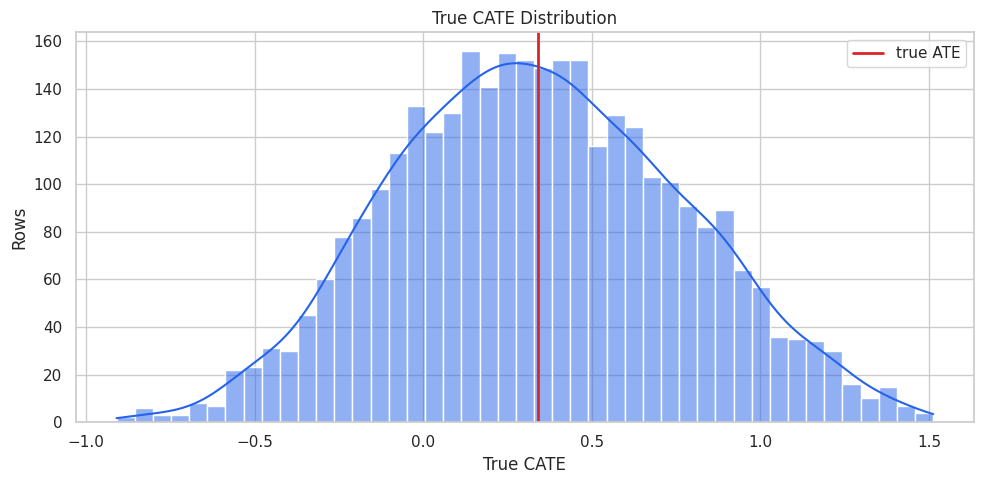

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(teaching_df["true_cate"], bins=45, kde=True, color="#2563eb", ax=ax)
ax.axvline(teaching_df["true_cate"].mean(), color="#dc2626", linewidth=2, label="true ATE")
ax.set_title("True CATE Distribution")
ax.set_xlabel("True CATE")
ax.set_ylabel("Rows")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "08_true_cate_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

The treatment-effect distribution has meaningful spread. A global average alone would hide important differences across units.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->




### Raw Treated-versus-Control Difference

A raw outcome comparison is not a causal explanation. It mixes treatment effects with pre-existing differences between treated and untreated rows.

In [6]:
# Save the artifacts produced by the Raw Treated-Versus-Control Difference section.
raw_group_summary = (
    teaching_df.groupby("treatment")
    .agg(
        rows=("outcome", "size"),
        observed_outcome_mean=("outcome", "mean"),
        true_cate_mean=("true_cate", "mean"),
        propensity_mean=("propensity", "mean"),
        baseline_need_mean=("baseline_need", "mean"),
        friction_score_mean=("friction_score", "mean"),
        content_affinity_mean=("content_affinity", "mean"),
    )
    .reset_index()
)
raw_difference = (
    raw_group_summary.loc[raw_group_summary["treatment"].eq(1), "observed_outcome_mean"].iloc[0]
    - raw_group_summary.loc[raw_group_summary["treatment"].eq(0), "observed_outcome_mean"].iloc[0]
)
true_ate = teaching_df["true_cate"].mean()
raw_difference_summary = pd.DataFrame(
    [
        {"quantity": "raw treated minus untreated outcome mean", "value": raw_difference},
        {"quantity": "true ATE", "value": true_ate},
        {"quantity": "raw difference minus true ATE", "value": raw_difference - true_ate},
    ]
)

raw_group_summary.to_csv(TABLE_DIR / "08_raw_group_summary.csv", index=False)
raw_difference_summary.to_csv(TABLE_DIR / "08_raw_difference_vs_truth.csv", index=False)
display(raw_group_summary)
display(raw_difference_summary)


,treatment,rows,observed_outcome_mean,true_cate_mean,propensity_mean,baseline_need_mean,friction_score_mean,content_affinity_mean
0,0,1675,1.8976,0.2431,0.3426,-0.4341,-0.3150,-0.1486
1,1,1525,3.0182,0.4462,0.6100,0.4090,0.2758,0.1816


,quantity,value
0,raw treated minus untreated outcome mean,1.1206
1,true ATE,0.3399
2,raw difference minus true ATE,0.7807


Treated rows are different before treatment. Explaining a CATE model only makes sense after we acknowledge the observational design and adjustment problem.



### Covariate Balance Check

Standardized mean differences show pre-treatment imbalance between treated and untreated groups. Large values flag observed confounding.

In [7]:
balance_rows = []
for col in all_observed_covariates:
    treated_values = teaching_df.loc[teaching_df["treatment"].eq(1), col]
    control_values = teaching_df.loc[teaching_df["treatment"].eq(0), col]
    pooled_sd = np.sqrt((treated_values.var(ddof=1) + control_values.var(ddof=1)) / 2)
    balance_rows.append(
        {
            "covariate": col,
            "treated_mean": treated_values.mean(),
            "control_mean": control_values.mean(),
            "standardized_difference": (treated_values.mean() - control_values.mean()) / pooled_sd,
        }
    )

balance_table = pd.DataFrame(balance_rows).sort_values("standardized_difference", key=lambda s: s.abs(), ascending=False)
balance_table.to_csv(TABLE_DIR / "08_covariate_balance.csv", index=False)
display(balance_table)


,covariate,treated_mean,control_mean,standardized_difference
0,baseline_need,0.4090,-0.4341,0.9200
6,high_need_segment,0.4472,0.1421,0.7100
2,friction_score,0.2758,-0.3150,0.5967
1,prior_engagement,0.2046,-0.1278,0.3345
3,content_affinity,0.1816,-0.1486,0.3195
10,seasonality_index,0.1022,-0.1302,0.2378
9,account_tenure,-0.1098,0.0941,-0.2028
12,traffic_intensity,0.0877,-0.0902,0.1820
7,trust_score,-0.0502,0.0867,-0.1358
5,region_risk,0.3554,0.3134,0.0890


Several effect-driving features are also treatment-assignment predictors. That is why the CATE model needs nuisance adjustment before explanations are meaningful.

The causal implication is indirect but important: these diagnostics tell us whether the modeling stage is stable enough to support the causal estimate.
<!-- result-implication-expanded -->


#### Covariate Balance Plot

The plot highlights the most imbalanced pre-treatment features.

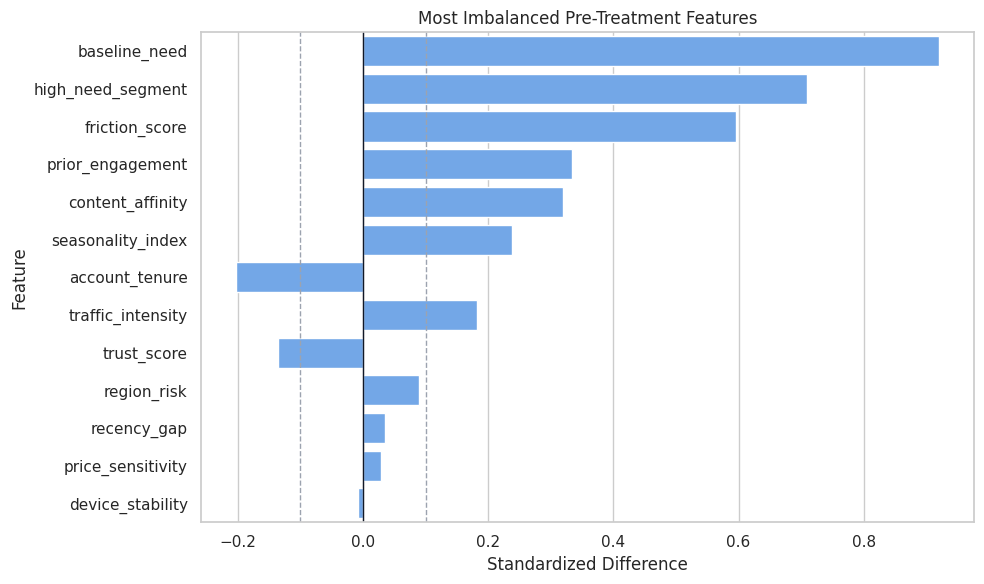

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=balance_table.head(13),
    x="standardized_difference",
    y="covariate",
    color="#60a5fa",
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.axvline(0.10, color="#9ca3af", linewidth=1, linestyle="--")
ax.axvline(-0.10, color="#9ca3af", linewidth=1, linestyle="--")
ax.set_title("Most Imbalanced Pre-Treatment Features")
ax.set_xlabel("Standardized Difference")
ax.set_ylabel("Feature")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "08_covariate_balance.png", dpi=160, bbox_inches="tight")
plt.show()


Explanation outputs later should not be read as if treatment were randomized. The model is adjusting for observed structure in a non-random assignment process.

#### Propensity Overlap

Overlap affects how much support the data has for comparing treated and untreated rows. Weak overlap makes both estimation and explanation more fragile.

In [9]:
propensity_summary = (
    teaching_df.assign(propensity_bucket=pd.cut(teaching_df["propensity"], bins=np.linspace(0, 1, 11), include_lowest=True))
    .groupby("propensity_bucket", observed=True)
    .agg(
        rows=("propensity", "size"),
        treatment_rate=("treatment", "mean"),
        true_cate_mean=("true_cate", "mean"),
        baseline_need_mean=("baseline_need", "mean"),
    )
    .reset_index()
)
propensity_summary["propensity_bucket"] = propensity_summary["propensity_bucket"].astype(str)
propensity_summary.to_csv(TABLE_DIR / "08_propensity_bucket_summary.csv", index=False)
display(propensity_summary)


,propensity_bucket,rows,treatment_rate,true_cate_mean,baseline_need_mean
0,"(-0.001, 0.1]",203,0.0739,0.0212,-1.5850
1,"(0.1, 0.2]",389,0.1620,0.0781,-0.9870
2,"(0.2, 0.3]",386,0.2409,0.1885,-0.6021
3,"(0.3, 0.4]",405,0.3333,0.2129,-0.3225
4,"(0.4, 0.5]",385,0.4597,0.2861,-0.0878
5,"(0.5, 0.6]",374,0.5321,0.3805,0.1839
6,"(0.6, 0.7]",333,0.7027,0.5143,0.4930
7,"(0.7, 0.8]",301,0.7807,0.5372,0.7416
8,"(0.8, 0.9]",283,0.8551,0.7084,1.1198
9,"(0.9, 1.0]",141,0.9362,0.7654,1.6031


Most rows have usable support, but treatment rates shift across propensity buckets. Explanations in extreme regions should be treated with extra caution.

#### Propensity Overlap Plot

The histogram shows true propensity by observed treatment group. In real data, this would use an estimated propensity model.

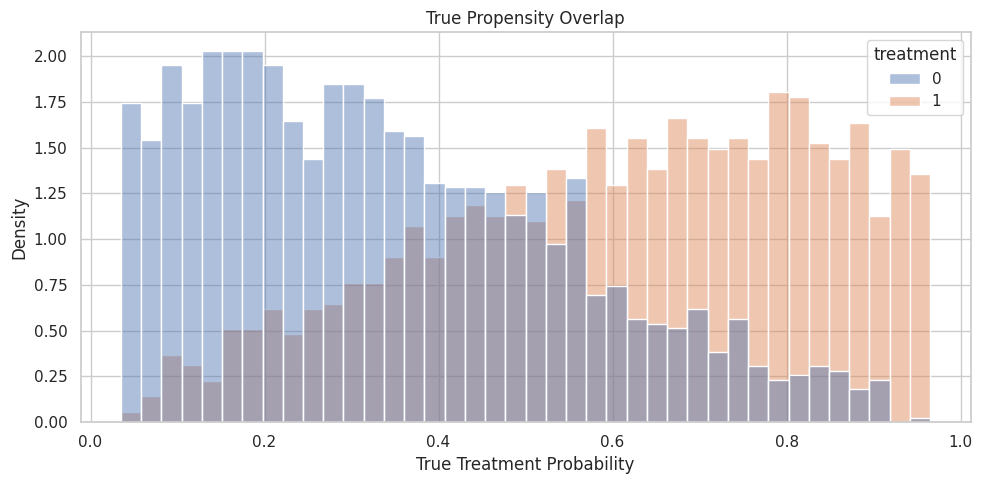

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=teaching_df,
    x="propensity",
    hue="treatment",
    bins=40,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=ax,
)
ax.set_title("True Propensity Overlap")
ax.set_xlabel("True Treatment Probability")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "08_propensity_overlap.png", dpi=160, bbox_inches="tight")
plt.show()


There is overlap, but the distributions are not identical. This is a realistic setting for model explanation after adjustment.

For causal interpretation, this is a support check: weak overlap can make an estimator depend on extrapolation instead of comparable treated and control units.
<!-- result-implication-expanded -->




#### Train and Test Split

The train set fits the CATE models. The test set evaluates CATE recovery and explanation summaries against known truth.

In [11]:
train_idx, test_idx = train_test_split(
    teaching_df.index,
    test_size=0.35,
    random_state=RANDOM_SEED,
    stratify=teaching_df["treatment"],
)
train_df = teaching_df.loc[train_idx].reset_index(drop=True)
test_df = teaching_df.loc[test_idx].reset_index(drop=True)

split_summary = pd.DataFrame(
    [
        {"split": "train", "rows": len(train_df), "treatment_rate": train_df["treatment"].mean(), "true_ate": train_df["true_cate"].mean()},
        {"split": "test", "rows": len(test_df), "treatment_rate": test_df["treatment"].mean(), "true_ate": test_df["true_cate"].mean()},
    ]
)

split_summary.to_csv(TABLE_DIR / "08_train_test_split_summary.csv", index=False)
display(split_summary)


,split,rows,treatment_rate,true_ate
0,train,2080,0.4764,0.3470
1,test,1120,0.4768,0.3266


The split keeps treatment rates and true ATEs similar, making model and explanation checks easier to compare.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


#### Modeling Matrices

The code below creates the arrays passed to EconML. `X` contains effect modifiers for the CATE surface, while `W` contains additional controls for nuisance adjustment.

In [12]:
Y_train = train_df["outcome"].to_numpy()
T_train = train_df["treatment"].to_numpy()
Y_test = test_df["outcome"].to_numpy()
T_test = test_df["treatment"].to_numpy()

X_train = train_df[effect_modifier_cols]
X_test = test_df[effect_modifier_cols]
W_train = train_df[control_cols]
W_test = test_df[control_cols]
all_features_train = train_df[all_observed_covariates]
all_features_test = test_df[all_observed_covariates]
true_cate_train = train_df["true_cate"].to_numpy()
true_cate_test = test_df["true_cate"].to_numpy()

matrix_summary = pd.DataFrame(
    [
        {"object": "Y_train", "rows": Y_train.shape[0], "columns": 1, "meaning": "Observed outcome."},
        {"object": "T_train", "rows": T_train.shape[0], "columns": 1, "meaning": "Observed binary treatment."},
        {"object": "X_train", "rows": X_train.shape[0], "columns": X_train.shape[1], "meaning": "Effect modifiers used by CATE model and explanations."},
        {"object": "W_train", "rows": W_train.shape[0], "columns": W_train.shape[1], "meaning": "Additional controls for nuisance adjustment."},
        {"object": "true_cate_test", "rows": true_cate_test.shape[0], "columns": 1, "meaning": "Oracle effect used only for tutorial evaluation."},
    ]
)

matrix_summary.to_csv(TABLE_DIR / "08_model_matrix_summary.csv", index=False)
display(matrix_summary)


,object,rows,columns,meaning
0,Y_train,2080,1,Observed outcome.
1,T_train,2080,1,Observed binary treatment.
2,X_train,2080,7,Effect modifiers used by CATE model and explanations.
3,W_train,2080,6,Additional controls for nuisance adjustment.
4,true_cate_test,1120,1,Oracle effect used only for tutorial evaluation.


Explanations will focus on `X`, because those are the dimensions along which the CATE surface is reported.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->




### Nuisance Diagnostics

The CATE model uses nuisance adjustment. This separate diagnostic pass shows whether outcome and treatment are predictable from observed features.

In [13]:
outcome_probe = RandomForestRegressor(n_estimators=140, min_samples_leaf=20, random_state=RANDOM_SEED, n_jobs=-1)
treatment_probe = RandomForestClassifier(n_estimators=140, min_samples_leaf=20, random_state=RANDOM_SEED, n_jobs=-1)

outcome_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
treatment_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
y_oof = cross_val_predict(outcome_probe, all_features_train, Y_train, cv=outcome_cv, method="predict")
t_oof = cross_val_predict(treatment_probe, all_features_train, T_train, cv=treatment_cv, method="predict_proba")[:, 1]

nuisance_diagnostics = pd.DataFrame(
    [
        {"nuisance_model": "outcome E[Y | X, W]", "metric": "out_of_fold_rmse", "value": np.sqrt(mean_squared_error(Y_train, y_oof))},
        {"nuisance_model": "treatment E[T | X, W]", "metric": "out_of_fold_auc", "value": roc_auc_score(T_train, t_oof)},
        {"nuisance_model": "treatment E[T | X, W]", "metric": "out_of_fold_brier_score", "value": brier_score_loss(T_train, t_oof)},
        {"nuisance_model": "treatment E[T | X, W]", "metric": "out_of_fold_log_loss", "value": log_loss(T_train, t_oof)},
    ]
)

nuisance_diagnostics.to_csv(TABLE_DIR / "08_nuisance_diagnostics.csv", index=False)
display(nuisance_diagnostics)


,nuisance_model,metric,value
0,"outcome E[Y | X, W]",out_of_fold_rmse,1.1131
1,"treatment E[T | X, W]",out_of_fold_auc,0.7913
2,"treatment E[T | X, W]",out_of_fold_brier_score,0.1875
3,"treatment E[T | X, W]",out_of_fold_log_loss,0.5562


Treatment assignment is predictable, confirming observed confounding. The explanation layer should come after this adjustment-aware modeling setup.

This is a reproducibility check rather than causal evidence. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->




#### Fit CATE Models

We fit two models:

- `LinearDML` as a readable baseline;
- `CausalForestDML` as the main flexible CATE model to explain.

The forest is the focus because it captures nonlinear heterogeneity, but the linear baseline helps show what flexibility adds.

In [14]:
# Fit or evaluate the model objects used in the Fit CATE Models section.
if not ECONML_AVAILABLE:
    raise ImportError(f"EconML is not available in this environment: {ECONML_VERSION}")

linear_dml = LinearDML(
    model_y=RandomForestRegressor(n_estimators=120, min_samples_leaf=20, random_state=RANDOM_SEED + 1, n_jobs=-1),
    model_t=RandomForestClassifier(n_estimators=120, min_samples_leaf=20, random_state=RANDOM_SEED + 1, n_jobs=-1),
    discrete_treatment=True,
    fit_cate_intercept=True,
    cv=5,
    random_state=RANDOM_SEED,
)
linear_dml.fit(Y_train, T_train, X=X_train, W=W_train, inference=None)
linear_cate_test = np.ravel(linear_dml.effect(X_test))

causal_forest = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=140, min_samples_leaf=20, random_state=RANDOM_SEED + 2, n_jobs=-1),
    model_t=RandomForestClassifier(n_estimators=140, min_samples_leaf=20, random_state=RANDOM_SEED + 2, n_jobs=-1),
    discrete_treatment=True,
    cv=5,
    n_estimators=220,
    min_samples_leaf=18,
    max_samples=0.45,
    honest=True,
    inference=True,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
causal_forest.fit(Y_train, T_train, X=X_train, W=W_train)
forest_cate_train = np.ravel(causal_forest.effect(X_train))
forest_cate_test = np.ravel(causal_forest.effect(X_test))
forest_lower_test, forest_upper_test = causal_forest.effect_interval(X_test, alpha=0.05)
forest_lower_test = np.ravel(forest_lower_test)
forest_upper_test = np.ravel(forest_upper_test)

cate_model_summary = pd.DataFrame(
    [
        {"model": "LinearDML", "estimated_ate": linear_cate_test.mean(), "true_ate": true_cate_test.mean(), "ate_error": linear_cate_test.mean() - true_cate_test.mean(), "cate_rmse": np.sqrt(mean_squared_error(true_cate_test, linear_cate_test)), "cate_spearman": pd.Series(linear_cate_test).corr(pd.Series(true_cate_test), method="spearman")},
        {"model": "CausalForestDML", "estimated_ate": forest_cate_test.mean(), "true_ate": true_cate_test.mean(), "ate_error": forest_cate_test.mean() - true_cate_test.mean(), "cate_rmse": np.sqrt(mean_squared_error(true_cate_test, forest_cate_test)), "cate_spearman": pd.Series(forest_cate_test).corr(pd.Series(true_cate_test), method="spearman")},
    ]
)

cate_model_summary.to_csv(TABLE_DIR / "08_cate_model_summary.csv", index=False)
display(cate_model_summary)


,model,estimated_ate,true_ate,ate_error,cate_rmse,cate_spearman
0,LinearDML,0.3380,0.3266,0.0114,0.1803,0.9177
1,CausalForestDML,0.3284,0.3266,0.0018,0.2475,0.8622


The forest is the main model to explain because it estimates a flexible CATE surface. We still check recovery first, because explanations of a poor CATE model are not very useful.



#### CATE Recovery Plot

The scatter plot compares estimated CATE with known true CATE. The dashed diagonal marks perfect recovery.

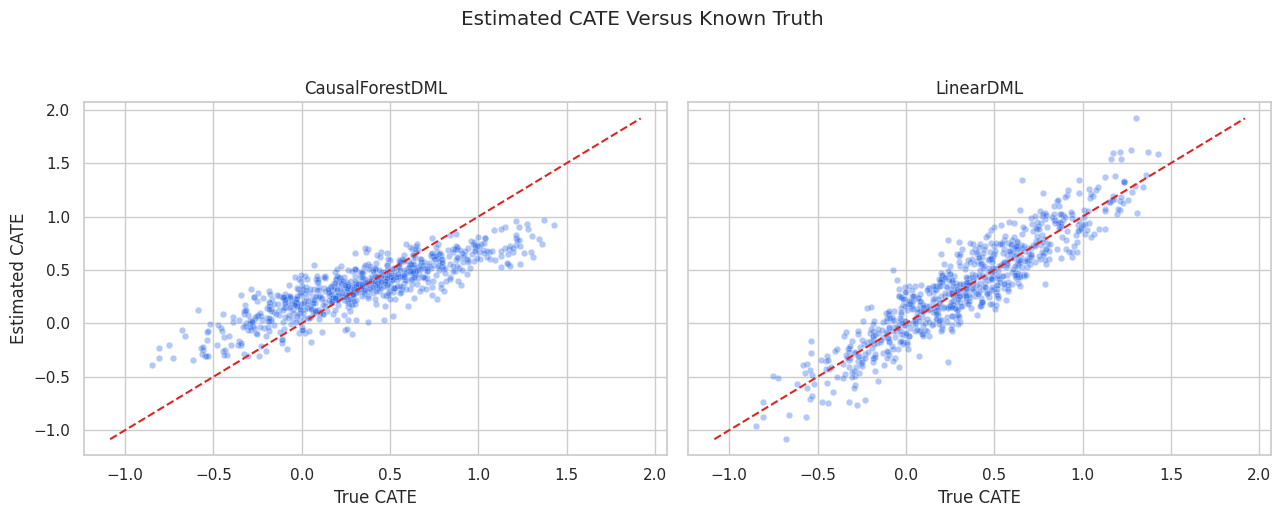

In [15]:
cate_plot_df = pd.concat(
    [
        pd.DataFrame({"true_cate": true_cate_test, "estimated_cate": linear_cate_test, "model": "LinearDML"}),
        pd.DataFrame({"true_cate": true_cate_test, "estimated_cate": forest_cate_test, "model": "CausalForestDML"}),
    ],
    ignore_index=True,
)
limits = [
    min(cate_plot_df["true_cate"].min(), cate_plot_df["estimated_cate"].min()),
    max(cate_plot_df["true_cate"].max(), cate_plot_df["estimated_cate"].max()),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, (model_name, model_df) in zip(axes, cate_plot_df.groupby("model")):
    sample_df = model_df.sample(n=min(750, len(model_df)), random_state=RANDOM_SEED)
    sns.scatterplot(data=sample_df, x="true_cate", y="estimated_cate", alpha=0.35, s=22, color="#2563eb", ax=ax)
    ax.plot(limits, limits, color="#dc2626", linestyle="--", linewidth=1.5)
    ax.set_title(model_name)
    ax.set_xlabel("True CATE")
    ax.set_ylabel("Estimated CATE")

plt.suptitle("Estimated CATE Versus Known Truth", y=1.03)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "08_cate_recovery_scatter.png", dpi=160, bbox_inches="tight")
plt.show()


The forest captures the broad treatment-effect ranking, but individual estimates remain noisy. Explanation should focus on stable patterns, not one-row certainty.

### Forest Feature Importance

`CausalForestDML` exposes feature importance for the CATE model. This is the first global explanation layer.

In [16]:
forest_importance = pd.DataFrame(
    {
        "feature": effect_modifier_cols,
        "importance": np.ravel(causal_forest.feature_importances_),
        "true_cate_driver": [col in true_driver_cols for col in effect_modifier_cols],
    }
).sort_values("importance", ascending=False)

forest_importance.to_csv(TABLE_DIR / "08_causal_forest_feature_importance.csv", index=False)
display(forest_importance)

,feature,importance,true_cate_driver
2,friction_score,0.3799,True
3,content_affinity,0.2788,True
0,baseline_need,0.1918,True
1,prior_engagement,0.1021,True
4,price_sensitivity,0.0439,True
5,region_risk,0.0033,True
6,high_need_segment,0.0003,True


The forest importance table says which features the fitted CATE model used most. It does not prove that those variables are sufficient for causal identification.

#### Forest Feature Importance Plot

The plot makes the forest importance ranking easier to scan.

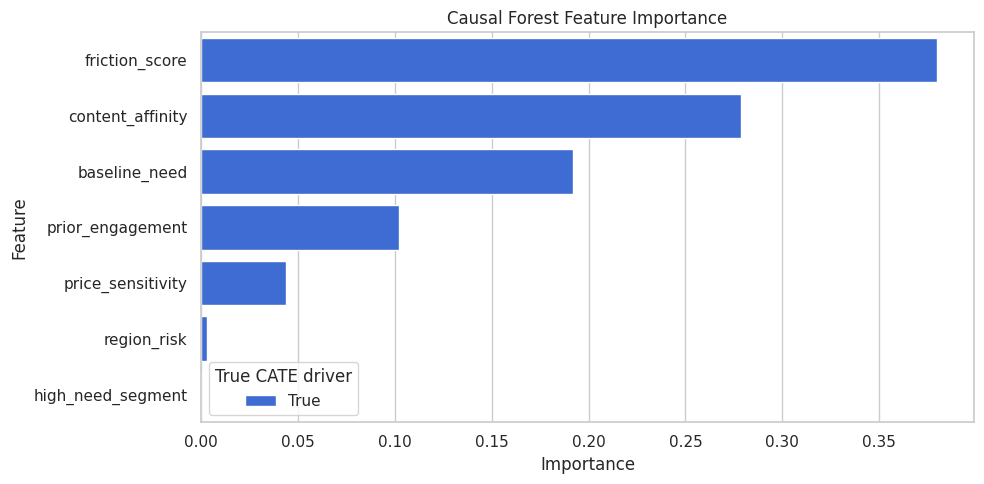

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=forest_importance,
    x="importance",
    y="feature",
    hue="true_cate_driver",
    dodge=False,
    palette={True: "#2563eb", False: "#9ca3af"},
    ax=ax,
)
ax.set_title("Causal Forest Feature Importance")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
ax.legend(title="True CATE driver")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "08_causal_forest_feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()


Global importance gives the first story about the CATE surface. The next sections test that story with surrogate SHAP values and segment summaries.



#### Train a Surrogate CATE Model for SHAP

SHAP explains a prediction model. EconML CATE estimators are not always directly supported by every SHAP explainer, so a practical workflow is:

1. Fit the causal model.
2. Predict CATE on a feature matrix.
3. Train a surrogate supervised model to predict those CATE estimates from `X`.
4. Check surrogate fidelity.
5. Use SHAP on the surrogate.

This explains the fitted CATE surface, not the original outcome model.

In [18]:
surrogate_model = RandomForestRegressor(
    n_estimators=260,
    min_samples_leaf=15,
    random_state=RANDOM_SEED + 10,
    n_jobs=-1,
)
surrogate_model.fit(X_train, forest_cate_train)
surrogate_cate_test = surrogate_model.predict(X_test)

surrogate_fidelity = pd.DataFrame(
    [
        {"metric": "surrogate_rmse_vs_forest_cate", "value": np.sqrt(mean_squared_error(forest_cate_test, surrogate_cate_test))},
        {"metric": "surrogate_correlation_vs_forest_cate", "value": np.corrcoef(forest_cate_test, surrogate_cate_test)[0, 1]},
        {"metric": "surrogate_spearman_vs_forest_cate", "value": pd.Series(surrogate_cate_test).corr(pd.Series(forest_cate_test), method="spearman")},
        {"metric": "surrogate_rmse_vs_true_cate", "value": np.sqrt(mean_squared_error(true_cate_test, surrogate_cate_test))},
        {"metric": "forest_rmse_vs_true_cate", "value": np.sqrt(mean_squared_error(true_cate_test, forest_cate_test))},
    ]
)

surrogate_fidelity.to_csv(TABLE_DIR / "08_surrogate_fidelity.csv", index=False)
display(surrogate_fidelity)


,metric,value
0,surrogate_rmse_vs_forest_cate,0.0671
1,surrogate_correlation_vs_forest_cate,0.9662
2,surrogate_spearman_vs_forest_cate,0.9599
3,surrogate_rmse_vs_true_cate,0.2621
4,forest_rmse_vs_true_cate,0.2475


SHAP explanations are useful only if the surrogate closely mimics the forest CATE predictions. The fidelity table sets the credibility level for the rest of the SHAP section.

#### Compute SHAP Values for the Surrogate

The code below computes SHAP values for the surrogate CATE model on the test set. Each SHAP value estimates how much a feature contributes to the surrogate's estimated CATE for a row.

In [19]:
if not SHAP_AVAILABLE:
    raise ImportError(f"SHAP is not available in this environment: {SHAP_VERSION}")

shap_explainer = shap.TreeExplainer(surrogate_model)
shap_values = shap_explainer.shap_values(X_test)
shap_values = np.asarray(shap_values)
expected_surrogate_cate = float(np.ravel(shap_explainer.expected_value)[0])

shap_importance = pd.DataFrame(
    {
        "feature": effect_modifier_cols,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
        "mean_shap": shap_values.mean(axis=0),
        "true_cate_driver": [col in true_driver_cols for col in effect_modifier_cols],
    }
).sort_values("mean_abs_shap", ascending=False)

shap_importance.to_csv(TABLE_DIR / "08_surrogate_shap_importance.csv", index=False)
print(f"Expected surrogate CATE baseline: {expected_surrogate_cate:.4f}")
display(shap_importance)


Expected surrogate CATE baseline: 0.3462


,feature,mean_abs_shap,mean_shap,true_cate_driver
3,content_affinity,0.1215,-0.0031,True
2,friction_score,0.0980,-0.0103,True
0,baseline_need,0.0623,0.0027,True
1,prior_engagement,0.0526,-0.0041,True
4,price_sensitivity,0.0159,0.0004,True
6,high_need_segment,0.0026,0.0004,True
5,region_risk,0.0000,0.0000,True


Mean absolute SHAP values rank the features that most move surrogate CATE predictions away from the baseline prediction.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->


#### SHAP Importance Plot

The SHAP importance plot summarizes global contribution size. Larger values mean a feature more strongly changes surrogate CATE predictions across the test set.

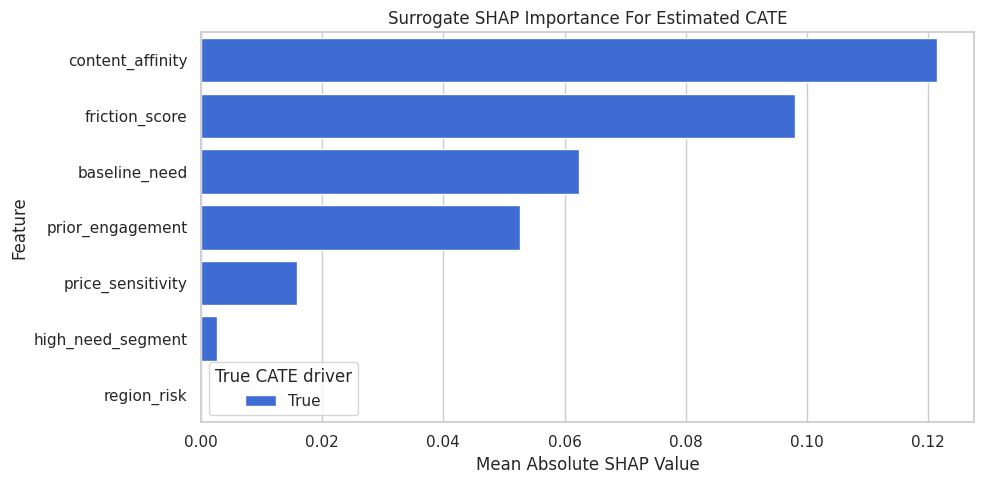

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=shap_importance,
    x="mean_abs_shap",
    y="feature",
    hue="true_cate_driver",
    dodge=False,
    palette={True: "#2563eb", False: "#9ca3af"},
    ax=ax,
)
ax.set_title("Surrogate SHAP Importance For Estimated CATE")
ax.set_xlabel("Mean Absolute SHAP Value")
ax.set_ylabel("Feature")
ax.legend(title="True CATE driver")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "08_surrogate_shap_importance.png", dpi=160, bbox_inches="tight")
plt.show()


SHAP and forest importance should tell broadly compatible stories when the surrogate has high fidelity. Disagreements are a reason to inspect the model more carefully.

#### SHAP Beeswarm-Style Plot

A beeswarm-style plot shows both direction and spread. Points to the right push estimated CATE higher; points to the left push estimated CATE lower. Color shows the feature value.

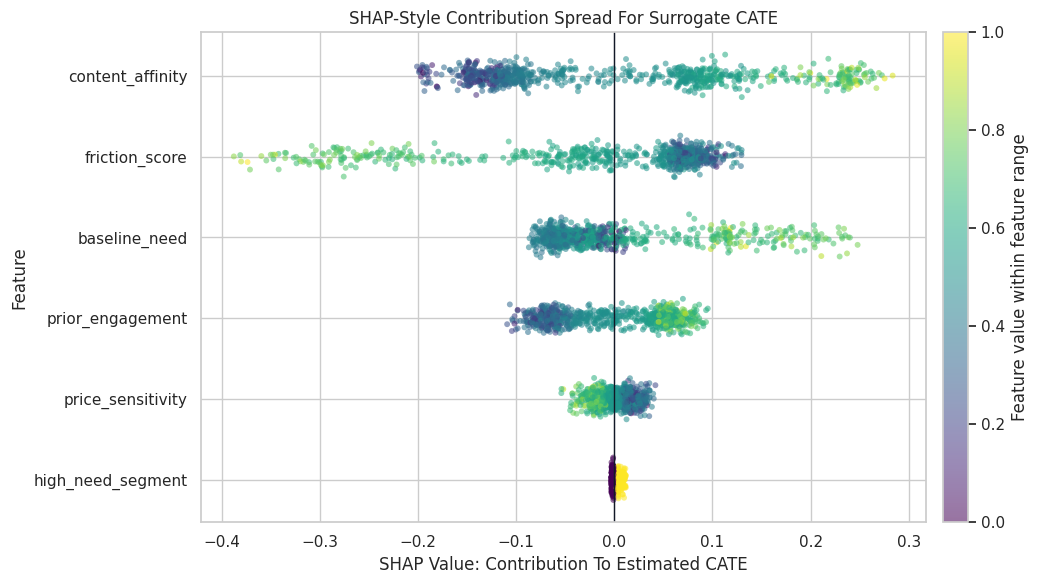

In [21]:
# Build and label the diagnostic visualization for the SHAP Beeswarm-Style Plot section.
top_shap_features = shap_importance.head(6)["feature"].tolist()
feature_order = top_shap_features[::-1]
plot_sample_idx = np.arange(len(X_test))
if len(plot_sample_idx) > 800:
    plot_sample_idx = rng.choice(plot_sample_idx, size=800, replace=False)

fig, ax = plt.subplots(figsize=(11, 6))
for y_position, feature in enumerate(feature_order):
    feature_index = effect_modifier_cols.index(feature)
    x_values = shap_values[plot_sample_idx, feature_index]
    raw_feature_values = X_test.iloc[plot_sample_idx][feature].to_numpy()
    denom = np.nanmax(raw_feature_values) - np.nanmin(raw_feature_values)
    normalized = (raw_feature_values - np.nanmin(raw_feature_values)) / denom if denom > 0 else np.zeros_like(raw_feature_values)
    jitter = rng.normal(0, 0.08, size=len(plot_sample_idx))
    scatter = ax.scatter(
        x_values,
        np.full(len(plot_sample_idx), y_position) + jitter,
        c=normalized,
        cmap="viridis",
        alpha=0.55,
        s=18,
        edgecolors="none",
    )

ax.axvline(0, color="#111827", linewidth=1)
ax.set_yticks(range(len(feature_order)))
ax.set_yticklabels(feature_order)
ax.set_title("SHAP-Style Contribution Spread For Surrogate CATE")
ax.set_xlabel("SHAP Value: Contribution To Estimated CATE")
ax.set_ylabel("Feature")
cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Feature value within feature range")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "08_surrogate_shap_beeswarm_style.png", dpi=160, bbox_inches="tight")
plt.show()


A feature can matter in different directions for different rows. The spread view is more informative than a single importance number when heterogeneity is nonlinear.

#### Local SHAP Examples

Global summaries can hide row-level behavior. The next cell selects three rows: low estimated CATE, median estimated CATE, and high estimated CATE. For each row, we list the largest SHAP contributions.

In [22]:
# Save the artifacts produced by the Local SHAP Examples section.
ranked_test = test_df.assign(
    forest_cate=forest_cate_test,
    surrogate_cate=surrogate_cate_test,
    true_cate=true_cate_test,
).sort_values("forest_cate")

local_indices = {
    "low_estimated_cate": ranked_test.index[0],
    "median_estimated_cate": ranked_test.index[len(ranked_test) // 2],
    "high_estimated_cate": ranked_test.index[-1],
}

local_rows = []
for label, idx in local_indices.items():
    row_position = list(X_test.index).index(idx) if idx in X_test.index else idx
    shap_row = shap_values[row_position]
    feature_values = X_test.iloc[row_position]
    contribution_order = np.argsort(np.abs(shap_row))[::-1][:5]
    for feature_index in contribution_order:
        feature = effect_modifier_cols[feature_index]
        local_rows.append(
            {
                "case": label,
                "test_index": int(idx),
                "feature": feature,
                "feature_value": feature_values[feature],
                "shap_contribution": shap_row[feature_index],
                "surrogate_cate": surrogate_cate_test[row_position],
                "forest_cate": forest_cate_test[row_position],
                "true_cate": true_cate_test[row_position],
            }
        )

local_shap_table = pd.DataFrame(local_rows)
local_shap_table.to_csv(TABLE_DIR / "08_local_shap_examples.csv", index=False)
display(local_shap_table)


,case,test_index,feature,feature_value,shap_contribution,surrogate_cate,forest_cate,true_cate
0,low_estimated_cate,1039,friction_score,2.2045,-0.2969,-0.2824,-0.3907,-0.8493
1,low_estimated_cate,1039,content_affinity,-1.2924,-0.2011,-0.2824,-0.3907,-0.8493
2,low_estimated_cate,1039,prior_engagement,-2.1394,-0.0813,-0.2824,-0.3907,-0.8493
3,low_estimated_cate,1039,baseline_need,0.4433,-0.0302,-0.2824,-0.3907,-0.8493
4,low_estimated_cate,1039,price_sensitivity,1.1491,-0.0179,-0.2824,-0.3907,-0.8493
5,median_estimated_cate,321,content_affinity,-1.1554,-0.1576,0.3086,0.3333,0.2381
6,median_estimated_cate,321,friction_score,-0.6017,0.0849,0.3086,0.3333,0.2381
7,median_estimated_cate,321,prior_engagement,0.5815,0.0609,0.3086,0.3333,0.2381
8,median_estimated_cate,321,baseline_need,0.4304,-0.0211,0.3086,0.3333,0.2381
9,median_estimated_cate,321,price_sensitivity,0.1939,-0.0028,0.3086,0.3333,0.2381


Local explanations are useful for examples and debugging, but they should not be presented as precise individual causal truth. They explain one estimated CATE score.

#### Local SHAP Waterfall-Style Table

The code below reconstructs the surrogate prediction for the selected rows from the SHAP baseline plus feature contributions.

In [23]:
local_reconstruction_rows = []
for label, idx in local_indices.items():
    row_position = list(X_test.index).index(idx) if idx in X_test.index else idx
    shap_sum = expected_surrogate_cate + shap_values[row_position].sum()
    local_reconstruction_rows.append(
        {
            "case": label,
            "test_index": int(idx),
            "expected_surrogate_cate": expected_surrogate_cate,
            "sum_of_shap_contributions": shap_values[row_position].sum(),
            "reconstructed_surrogate_cate": shap_sum,
            "direct_surrogate_cate": surrogate_cate_test[row_position],
            "forest_cate": forest_cate_test[row_position],
            "true_cate": true_cate_test[row_position],
            "absolute_reconstruction_error": abs(shap_sum - surrogate_cate_test[row_position]),
        }
    )

local_reconstruction = pd.DataFrame(local_reconstruction_rows)
local_reconstruction.to_csv(TABLE_DIR / "08_local_shap_reconstruction.csv", index=False)
display(local_reconstruction)


,case,test_index,expected_surrogate_cate,sum_of_shap_contributions,reconstructed_surrogate_cate,direct_surrogate_cate,forest_cate,true_cate,absolute_reconstruction_error
0,low_estimated_cate,1039,0.3462,-0.6286,-0.2824,-0.2824,-0.3907,-0.8493,0.0000
1,median_estimated_cate,321,0.3462,-0.0376,0.3086,0.3086,0.3333,0.2381,0.0000
2,high_estimated_cate,1049,0.3462,0.5159,0.8621,0.8621,0.9837,1.3368,0.0000


SHAP values add up to the surrogate prediction. That arithmetic is about the surrogate model, so the forest CATE and true CATE columns are shown separately.



### Permutation CATE Sensitivity

Permutation sensitivity is another model-agnostic explanation. We shuffle one feature in `X_test`, recompute forest CATE, and measure how much predictions change.

In [24]:
# Define reusable helpers for the Permutation CATE Sensitivity section.
def cate_permutation_sensitivity(estimator, X_reference, feature_names, rng_seed=RANDOM_SEED):
    """
    Idea: Compute the CATE permutation sensitivity needed in the Permutation CATE Sensitivity section and return it in a form the next cells can inspect.
    
    Parameters
    ----------
    estimator : object
        Fitted causal estimator whose behavior is being inspected.
    X_reference : object
        Context-specific input used for X reference in this helper.
    feature_names : list[str]
        Covariate or effect-modifier names shown in outputs.
    rng_seed : int
        Seed value used to make `rng` reproducible.
    
    Returns
    -------
    pd.DataFrame
        Feature-sensitivity table showing how much CATE predictions change when each feature is permuted.
    """
    local_rng = np.random.default_rng(rng_seed)
    base_effect = np.ravel(estimator.effect(X_reference))
    rows = []
    for feature in feature_names:
        X_perm = X_reference.copy()
        X_perm[feature] = local_rng.permutation(X_perm[feature].to_numpy())
        perm_effect = np.ravel(estimator.effect(X_perm))
        rows.append(
            {
                "feature": feature,
                "mean_abs_cate_change": np.mean(np.abs(base_effect - perm_effect)),
                "rmse_cate_change": np.sqrt(mean_squared_error(base_effect, perm_effect)),
            }
        )
    return pd.DataFrame(rows).sort_values("mean_abs_cate_change", ascending=False)

permutation_sensitivity = cate_permutation_sensitivity(causal_forest, X_test, effect_modifier_cols)
permutation_sensitivity["true_cate_driver"] = permutation_sensitivity["feature"].isin(true_driver_cols)
permutation_sensitivity.to_csv(TABLE_DIR / "08_permutation_cate_sensitivity.csv", index=False)
display(permutation_sensitivity)


,feature,mean_abs_cate_change,rmse_cate_change,true_cate_driver
2,friction_score,0.1592,0.2288,True
3,content_affinity,0.1347,0.1765,True
0,baseline_need,0.1212,0.1701,True
1,prior_engagement,0.0796,0.1031,True
4,price_sensitivity,0.0521,0.0750,True
5,region_risk,0.0037,0.0068,True
6,high_need_segment,0.0006,0.0017,True


Permutation sensitivity asks a direct question: how much do CATE predictions change when this feature's relationship to the rows is broken?

#### Compare Explanation Rankings

This table combines forest importance, SHAP importance, and permutation sensitivity into one view.

In [25]:
combined_explanation_rankings = (
    forest_importance[["feature", "importance"]]
    .rename(columns={"importance": "forest_importance"})
    .merge(shap_importance[["feature", "mean_abs_shap"]], on="feature", how="left")
    .merge(permutation_sensitivity[["feature", "mean_abs_cate_change"]], on="feature", how="left")
)
combined_explanation_rankings["forest_rank"] = combined_explanation_rankings["forest_importance"].rank(ascending=False, method="min")
combined_explanation_rankings["shap_rank"] = combined_explanation_rankings["mean_abs_shap"].rank(ascending=False, method="min")
combined_explanation_rankings["permutation_rank"] = combined_explanation_rankings["mean_abs_cate_change"].rank(ascending=False, method="min")
combined_explanation_rankings["true_cate_driver"] = combined_explanation_rankings["feature"].isin(true_driver_cols)
combined_explanation_rankings = combined_explanation_rankings.sort_values("shap_rank")

combined_explanation_rankings.to_csv(TABLE_DIR / "08_combined_explanation_rankings.csv", index=False)
display(combined_explanation_rankings)


,feature,forest_importance,mean_abs_shap,mean_abs_cate_change,forest_rank,shap_rank,permutation_rank,true_cate_driver
1,content_affinity,0.2788,0.1215,0.1347,2.0000,1.0000,2.0000,True
0,friction_score,0.3799,0.0980,0.1592,1.0000,2.0000,1.0000,True
2,baseline_need,0.1918,0.0623,0.1212,3.0000,3.0000,3.0000,True
3,prior_engagement,0.1021,0.0526,0.0796,4.0000,4.0000,4.0000,True
4,price_sensitivity,0.0439,0.0159,0.0521,5.0000,5.0000,5.0000,True
6,high_need_segment,0.0003,0.0026,0.0006,7.0000,6.0000,7.0000,True
5,region_risk,0.0033,0.0000,0.0037,6.0000,7.0000,6.0000,True


Explanation methods should usually agree on the strongest drivers. If they strongly disagree, the model may be unstable or the features may be correlated.



#### Combined Explanation Plot

The plot compares normalized importance from the three explanation methods.

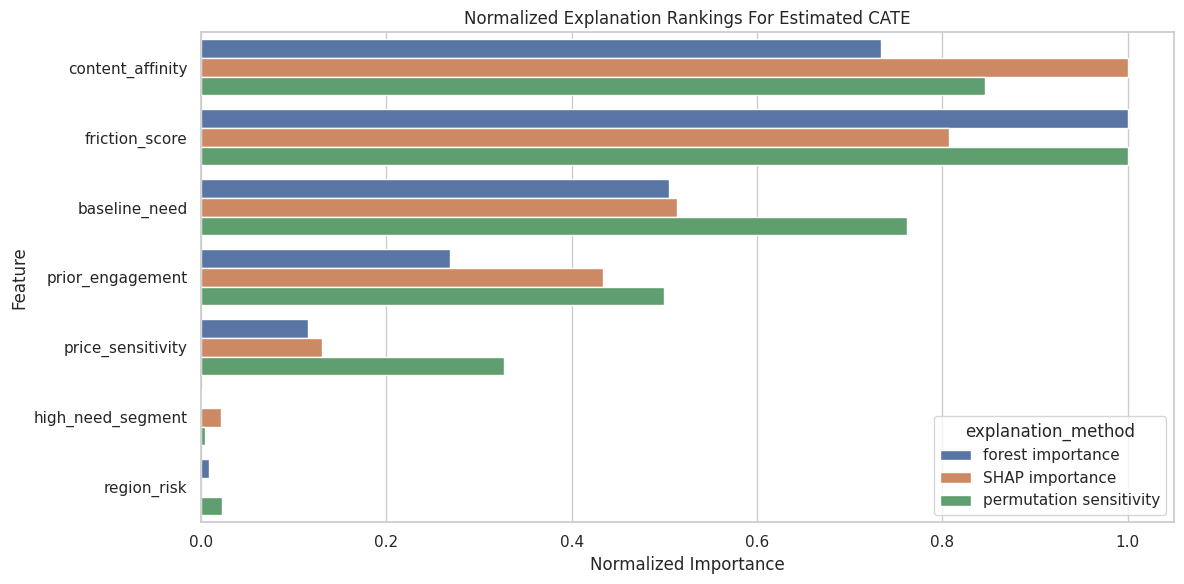

In [26]:
# Build and label the diagnostic visualization for the Combined Explanation Plot section.
normalized_explanations = combined_explanation_rankings.copy()
for col in ["forest_importance", "mean_abs_shap", "mean_abs_cate_change"]:
    max_value = normalized_explanations[col].max()
    normalized_explanations[col + "_normalized"] = normalized_explanations[col] / max_value if max_value > 0 else 0

explanation_plot_df = normalized_explanations.melt(
    id_vars=["feature", "true_cate_driver"],
    value_vars=["forest_importance_normalized", "mean_abs_shap_normalized", "mean_abs_cate_change_normalized"],
    var_name="explanation_method",
    value_name="normalized_importance",
)
explanation_plot_df["explanation_method"] = explanation_plot_df["explanation_method"].replace(
    {
        "forest_importance_normalized": "forest importance",
        "mean_abs_shap_normalized": "SHAP importance",
        "mean_abs_cate_change_normalized": "permutation sensitivity",
    }
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=explanation_plot_df,
    x="normalized_importance",
    y="feature",
    hue="explanation_method",
    ax=ax,
)
ax.set_title("Normalized Explanation Rankings For Estimated CATE")
ax.set_xlabel("Normalized Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "08_combined_explanation_rankings.png", dpi=160, bbox_inches="tight")
plt.show()


Using multiple explanation methods keeps us honest. We are looking for stable themes, not over-reading one metric.

The figure matters because it turns the numeric output into a pattern that can be inspected before trusting the next modeling step.
<!-- result-implication-expanded -->





## Reporting and Takeaways

### Segment-Level CATE Summary

Segment summaries make CATE models easier to audit. Here we summarize by high-need segment and region risk.

In [27]:
# Save the artifacts produced by the Segment-Level CATE Summary section.
test_results = test_df.assign(
    linear_cate=linear_cate_test,
    forest_cate=forest_cate_test,
    surrogate_cate=surrogate_cate_test,
    forest_ci_lower=forest_lower_test,
    forest_ci_upper=forest_upper_test,
    forest_ci_width=forest_upper_test - forest_lower_test,
)

segment_summary = (
    test_results.groupby(["high_need_segment", "region_risk"], observed=True)
    .agg(
        rows=("outcome", "size"),
        true_cate=("true_cate", "mean"),
        linear_cate=("linear_cate", "mean"),
        forest_cate=("forest_cate", "mean"),
        surrogate_cate=("surrogate_cate", "mean"),
        forest_ci_width=("forest_ci_width", "mean"),
        treatment_rate=("treatment", "mean"),
        propensity_mean=("propensity", "mean"),
    )
    .reset_index()
)
segment_summary["forest_error"] = segment_summary["forest_cate"] - segment_summary["true_cate"]
segment_summary["linear_error"] = segment_summary["linear_cate"] - segment_summary["true_cate"]
segment_summary.to_csv(TABLE_DIR / "08_segment_cate_summary.csv", index=False)
display(segment_summary)


,high_need_segment,region_risk,rows,true_cate,linear_cate,forest_cate,surrogate_cate,forest_ci_width,treatment_rate,propensity_mean,forest_error,linear_error
0,0,0,543,0.2851,0.1976,0.3048,0.3168,0.5481,0.3665,0.3514,0.0197,-0.0875
1,0,1,254,0.1231,0.2572,0.3132,0.3194,0.5784,0.3858,0.4031,0.1901,0.1341
2,1,0,213,0.6005,0.6057,0.3886,0.3781,0.6744,0.7089,0.7114,-0.2120,0.0052
3,1,1,110,0.4708,0.6988,0.3634,0.3490,0.6893,0.7818,0.7674,-0.1075,0.2280


Segment summaries connect model explanation to group-level reporting. The interval-width column also shows where the forest is less certain.

The later estimates should be read in light of this sample construction, since data quality and composition set the boundary for any causal claim.
<!-- result-implication-expanded -->




### Segment CATE Plot

This plot compares true and estimated CATE by segment.

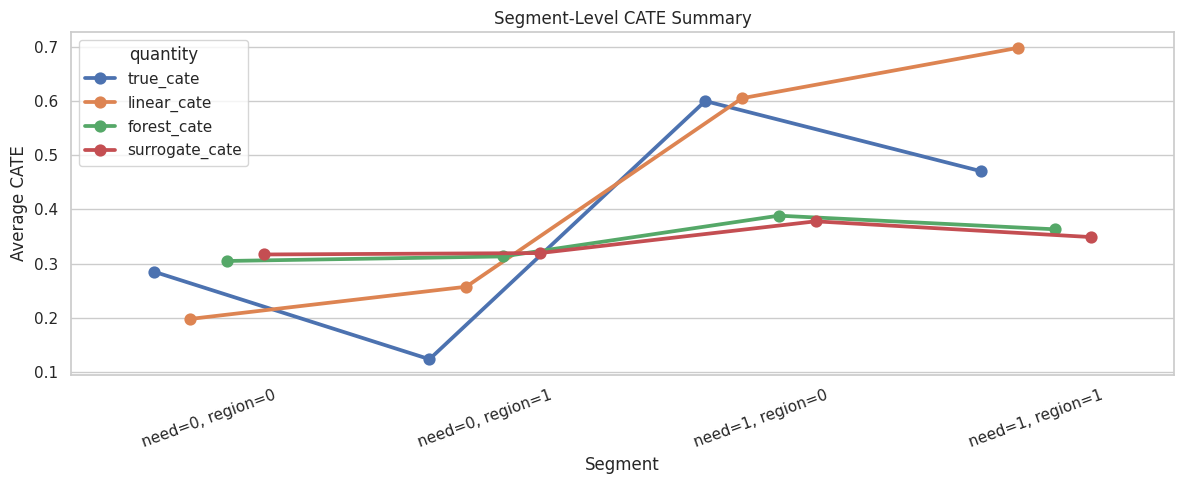

In [28]:
# Build and label the diagnostic visualization for the Segment CATE Plot section.
segment_plot_df = segment_summary.melt(
    id_vars=["high_need_segment", "region_risk", "rows"],
    value_vars=["true_cate", "linear_cate", "forest_cate", "surrogate_cate"],
    var_name="quantity",
    value_name="average_cate",
)
segment_plot_df["segment"] = (
    "need=" + segment_plot_df["high_need_segment"].astype(str)
    + ", region=" + segment_plot_df["region_risk"].astype(str)
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.pointplot(
    data=segment_plot_df,
    x="segment",
    y="average_cate",
    hue="quantity",
    dodge=0.40,
    errorbar=None,
    ax=ax,
)
ax.set_title("Segment-Level CATE Summary")
ax.set_xlabel("Segment")
ax.set_ylabel("Average CATE")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "08_segment_cate_summary.png", dpi=160, bbox_inches="tight")
plt.show()


Segment plots make the heterogeneous-effect story more readable than unit-level estimates alone.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


### Two-Way Segment Heatmap

A heatmap can show CATE patterns across two continuous features after bucketing. Here we use baseline need and friction score.

In [29]:
heatmap_df = test_results.assign(
    need_bucket=pd.qcut(test_results["baseline_need"], q=5, labels=["very low", "low", "mid", "high", "very high"], duplicates="drop"),
    friction_bucket=pd.qcut(test_results["friction_score"], q=5, labels=["very low", "low", "mid", "high", "very high"], duplicates="drop"),
)
heatmap_summary = (
    heatmap_df.groupby(["need_bucket", "friction_bucket"], observed=True)
    .agg(
        rows=("outcome", "size"),
        true_cate=("true_cate", "mean"),
        forest_cate=("forest_cate", "mean"),
        forest_ci_width=("forest_ci_width", "mean"),
        propensity_mean=("propensity", "mean"),
    )
    .reset_index()
)
heatmap_summary.to_csv(TABLE_DIR / "08_need_friction_heatmap_summary.csv", index=False)

heatmap_matrix = heatmap_summary.pivot(index="need_bucket", columns="friction_bucket", values="forest_cate")
display(heatmap_summary.head(10))


,need_bucket,friction_bucket,rows,true_cate,forest_cate,forest_ci_width,propensity_mean
0,very low,very low,99,0.3039,0.4403,0.6420,0.1615
1,very low,low,57,0.3147,0.4197,0.6260,0.2172
2,very low,mid,28,0.1492,0.3106,0.5271,0.2449
3,very low,high,28,0.0582,0.1607,0.6502,0.2620
4,very low,very high,12,-0.1067,0.0401,0.6296,0.3401
5,low,very low,52,0.3714,0.3771,0.5323,0.3057
6,low,low,61,0.2130,0.2954,0.4725,0.2931
7,low,mid,53,0.2687,0.2912,0.5039,0.3634
8,low,high,37,-0.0371,0.1250,0.6027,0.3186
9,low,very high,21,-0.1427,-0.0131,0.6436,0.4154


Bucketing two features creates a compact surface view. The row counts are important because tiny cells can make segment averages unstable.

### Forest CATE Heatmap

The heatmap visualizes estimated CATE across baseline-need and friction-score buckets.

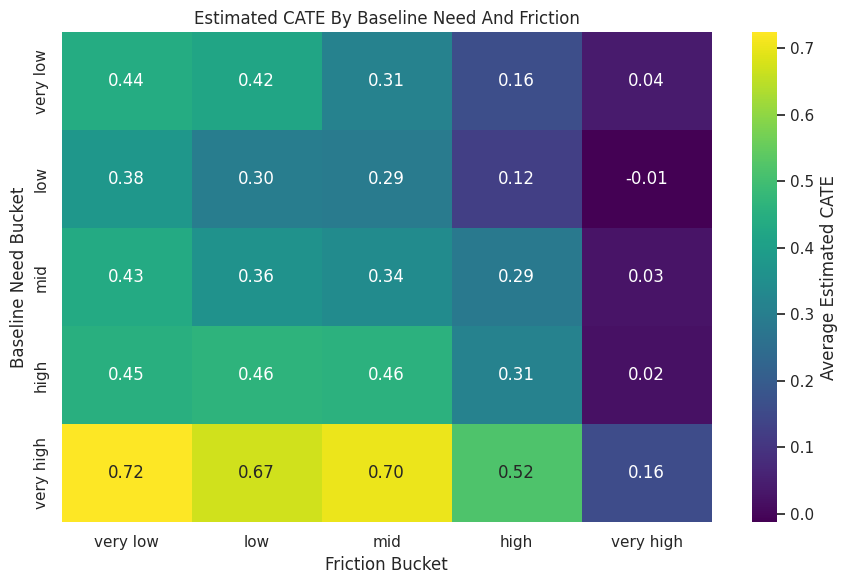

In [30]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    heatmap_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": "Average Estimated CATE"},
    ax=ax,
)
ax.set_title("Estimated CATE By Baseline Need And Friction")
ax.set_xlabel("Friction Bucket")
ax.set_ylabel("Baseline Need Bucket")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "08_need_friction_cate_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()


Heatmaps are strong communication tools when the chosen axes are meaningful. They should be shown with row counts or support diagnostics nearby.

### Effect Slice: Baseline Need

Effect slices show how CATE changes along one feature. For this slice, we vary baseline need while keeping other test-row features fixed, and we update `high_need_segment` consistently.

In [31]:
need_grid = np.linspace(X_test["baseline_need"].quantile(0.02), X_test["baseline_need"].quantile(0.98), 30)
reference_sample = X_test.sample(n=min(600, len(X_test)), random_state=RANDOM_SEED).copy()
need_slice_rows = []
for value in need_grid:
    modified = reference_sample.copy()
    modified["baseline_need"] = value
    modified["high_need_segment"] = (value > 0.55).astype(int) if hasattr(value, "astype") else int(value > 0.55)
    true_modified = true_cate_function(modified[effect_modifier_cols])
    need_slice_rows.append(
        {
            "baseline_need": value,
            "forest_cate": np.mean(causal_forest.effect(modified)),
            "surrogate_cate": np.mean(surrogate_model.predict(modified)),
            "true_cate": np.mean(true_modified),
        }
    )

need_slice = pd.DataFrame(need_slice_rows)
need_slice.to_csv(TABLE_DIR / "08_baseline_need_effect_slice.csv", index=False)
display(need_slice.head())


,baseline_need,forest_cate,surrogate_cate,true_cate
0,-2.1356,0.3292,0.3207,0.1583
1,-1.9941,0.3292,0.3207,0.1540
2,-1.8526,0.3331,0.3207,0.1510
3,-1.7111,0.3369,0.3207,0.1492
4,-1.5696,0.3373,0.3202,0.1489


Effect slices explain the model's average behavior along one feature. They are limited as a substitute for full multi-feature heterogeneity. They are very readable.

#### Baseline Need Slice Plot

The plot compares true, forest-estimated, and surrogate-estimated CATE along the baseline-need grid.

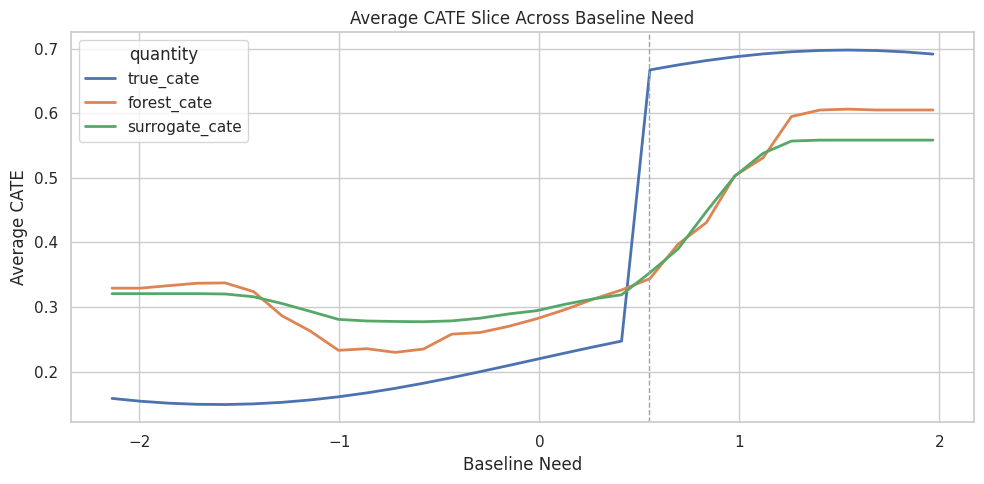

In [32]:
need_slice_plot = need_slice.melt(
    id_vars="baseline_need",
    value_vars=["true_cate", "forest_cate", "surrogate_cate"],
    var_name="quantity",
    value_name="average_cate",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=need_slice_plot, x="baseline_need", y="average_cate", hue="quantity", linewidth=2, ax=ax)
ax.axvline(0.55, color="#9ca3af", linestyle="--", linewidth=1, label="high-need threshold")
ax.set_title("Average CATE Slice Across Baseline Need")
ax.set_xlabel("Baseline Need")
ax.set_ylabel("Average CATE")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "08_baseline_need_effect_slice.png", dpi=160, bbox_inches="tight")
plt.show()


The slice makes a nonlinear threshold pattern visible. It also checks whether the surrogate follows the forest along an important feature.



#### Effect Slice: Friction Score

The true CATE has a penalty when friction is positive. This slice varies friction while keeping other features fixed.

In [33]:
friction_grid = np.linspace(X_test["friction_score"].quantile(0.02), X_test["friction_score"].quantile(0.98), 30)
friction_slice_rows = []
for value in friction_grid:
    modified = reference_sample.copy()
    modified["friction_score"] = value
    true_modified = true_cate_function(modified[effect_modifier_cols])
    friction_slice_rows.append(
        {
            "friction_score": value,
            "forest_cate": np.mean(causal_forest.effect(modified)),
            "surrogate_cate": np.mean(surrogate_model.predict(modified)),
            "true_cate": np.mean(true_modified),
        }
    )

friction_slice = pd.DataFrame(friction_slice_rows)
friction_slice.to_csv(TABLE_DIR / "08_friction_effect_slice.csv", index=False)
display(friction_slice.head())


,friction_score,forest_cate,surrogate_cate,true_cate
0,-2.1039,0.4229,0.4344,0.4260
1,-1.9602,0.4229,0.4344,0.4260
2,-1.8164,0.4210,0.4344,0.4260
3,-1.6726,0.4286,0.4344,0.4260
4,-1.5289,0.4213,0.4344,0.4260


Friction is expected to push treatment effects downward after it becomes positive. The slice checks whether the fitted model learned that shape.



#### Friction Slice Plot

The plot compares true and estimated average CATE across the friction-score grid.

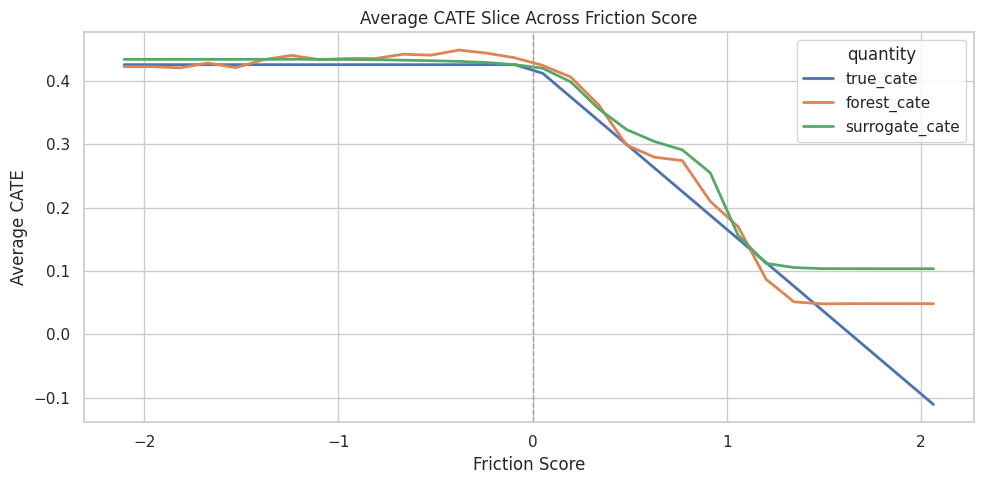

In [34]:
friction_slice_plot = friction_slice.melt(
    id_vars="friction_score",
    value_vars=["true_cate", "forest_cate", "surrogate_cate"],
    var_name="quantity",
    value_name="average_cate",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=friction_slice_plot, x="friction_score", y="average_cate", hue="quantity", linewidth=2, ax=ax)
ax.axvline(0, color="#9ca3af", linestyle="--", linewidth=1)
ax.set_title("Average CATE Slice Across Friction Score")
ax.set_xlabel("Friction Score")
ax.set_ylabel("Average CATE")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "08_friction_effect_slice.png", dpi=160, bbox_inches="tight")
plt.show()


Effect slices make model behavior tangible. They are especially useful when a global importance score says a feature matters but not how it matters.



#### High-Benefit Group Diagnostics

Explanation often leads to targeting. The code below compares the top 20 percent by estimated CATE with the oracle top 20 percent by true CATE.

In [35]:
# Define reusable helpers for the High-Benefit Group Diagnostics section.
def top_k_mask(score, fraction):
    """
    Idea: Select the observations with the largest predicted benefit under a capacity constraint.
    
    Parameters
    ----------
    score : object
        Score function or score name defining the estimating equation.
    fraction : object
        Fraction of rows or capacity selected by the policy rule.
    
    Returns
    -------
    np.ndarray
        Boolean mask selecting the highest-scoring observations under the capacity rule.
    """
    score = np.asarray(score)
    k = int(np.ceil(fraction * len(score)))
    mask = np.zeros(len(score), dtype=bool)
    if k > 0:
        mask[np.argsort(score)[-k:]] = True
    return mask

TOP_FRACTION = 0.20
estimated_top_mask = top_k_mask(forest_cate_test, TOP_FRACTION)
oracle_top_mask = top_k_mask(true_cate_test, TOP_FRACTION)

high_benefit_summary = pd.DataFrame(
    [
        {
            "group": "top 20 percent by forest CATE",
            "rows": int(estimated_top_mask.sum()),
            "true_cate_mean": true_cate_test[estimated_top_mask].mean(),
            "forest_cate_mean": forest_cate_test[estimated_top_mask].mean(),
            "forest_ci_width_mean": (forest_upper_test - forest_lower_test)[estimated_top_mask].mean(),
            "propensity_mean": test_df.loc[estimated_top_mask, "propensity"].mean(),
            "share_high_need_segment": test_df.loc[estimated_top_mask, "high_need_segment"].mean(),
            "share_region_risk": test_df.loc[estimated_top_mask, "region_risk"].mean(),
        },
        {
            "group": "top 20 percent by true CATE",
            "rows": int(oracle_top_mask.sum()),
            "true_cate_mean": true_cate_test[oracle_top_mask].mean(),
            "forest_cate_mean": forest_cate_test[oracle_top_mask].mean(),
            "forest_ci_width_mean": (forest_upper_test - forest_lower_test)[oracle_top_mask].mean(),
            "propensity_mean": test_df.loc[oracle_top_mask, "propensity"].mean(),
            "share_high_need_segment": test_df.loc[oracle_top_mask, "high_need_segment"].mean(),
            "share_region_risk": test_df.loc[oracle_top_mask, "region_risk"].mean(),
        },
        {
            "group": "all test rows",
            "rows": len(test_df),
            "true_cate_mean": true_cate_test.mean(),
            "forest_cate_mean": forest_cate_test.mean(),
            "forest_ci_width_mean": (forest_upper_test - forest_lower_test).mean(),
            "propensity_mean": test_df["propensity"].mean(),
            "share_high_need_segment": test_df["high_need_segment"].mean(),
            "share_region_risk": test_df["region_risk"].mean(),
        },
    ]
)

high_benefit_summary.to_csv(TABLE_DIR / "08_high_benefit_group_diagnostics.csv", index=False)
display(high_benefit_summary)


,group,rows,true_cate_mean,forest_cate_mean,forest_ci_width_mean,propensity_mean,share_high_need_segment,share_region_risk
0,top 20 percent by forest CATE,224,0.8751,0.6667,0.7033,0.6123,0.4866,0.3170
1,top 20 percent by true CATE,224,0.9442,0.6231,0.6498,0.6956,0.6071,0.2411
2,all test rows,1120,0.3266,0.3284,0.5928,0.4724,0.2884,0.3250


A top-CATE group should have higher true CATE than average in this simulation. We also inspect support and uncertainty, because high estimated benefit alone is not enough.



#### High-Benefit Group Plot

The plot compares average true CATE across the model-selected top group, the oracle top group, and all rows.

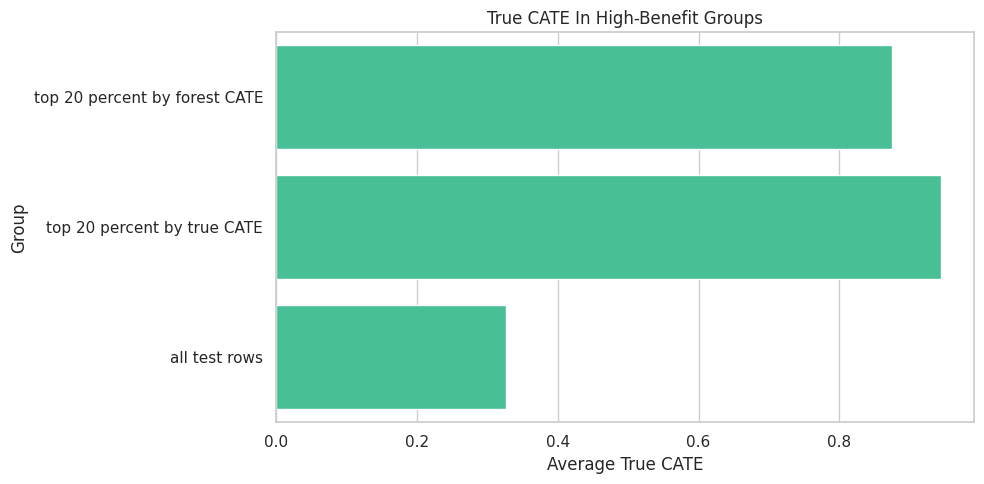

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=high_benefit_summary,
    x="true_cate_mean",
    y="group",
    color="#34d399",
    ax=ax,
)
ax.set_title("True CATE In High-Benefit Groups")
ax.set_xlabel("Average True CATE")
ax.set_ylabel("Group")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "08_high_benefit_group_diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()


Explanation and targeting connect here. If the explanation says high-need, low-friction users benefit more, the selected group should reflect that pattern and deliver higher true benefit in simulation.



#### Explanation Reporting Checklist

This table summarizes the habits that keep CATE explanation from becoming overclaiming.

| check | why_it_matters |
| --- | --- |
| Start with the causal design | Explanations of a poorly identified model are still poorly identified. |
| Separate model explanation from causal claims | Feature importance and SHAP explain fitted predictions, not identification assumptions. |
| Check CATE model recovery or validation | Explaining a weak model can produce a polished but misleading story. |
| Check surrogate fidelity before SHAP | SHAP on a surrogate is useful only if the surrogate mimics the CATE model. |
| Use multiple explanation views | Stable themes across importance, SHAP, permutation, and segments are more credible. |
| Report support and interval width | High estimated benefit in weak-support regions is risky. |
| Prefer segment summaries for communication | Segments are easier to audit than individual-level CATE explanations. |
| Avoid precise individual claims | Individual CATE estimates are usually noisy even when rankings are useful. |


The safest explanation story is layered and humble: model behavior, support, uncertainty, and segment-level patterns all shown together.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


#### Summary

This lesson explained a fitted CATE model using several complementary tools.

The main takeaways are:

- feature importance, SHAP values, and segment summaries explain fitted CATE estimates, not causal identification by themselves;
- CATE explanations should come after treatment, outcome, covariate, balance, and overlap checks;
- surrogate SHAP is useful when the surrogate has high fidelity to the CATE model;
- local SHAP examples are good for debugging and teaching, but should not be overused as precise individual causal truth;
- segment summaries and effect slices are often the clearest way to communicate heterogeneous effects;
- high-benefit groups should be checked for support, uncertainty, and true or validated value where possible;
- responsible reporting uses several explanation views and keeps the limitations visible.

The next tutorial can focus on uncertainty intervals and how to avoid overreacting to noisy CATE estimates.